In [ ]:
!pip install datasets

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import re

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
from datasets import load_dataset

In [ ]:
#this is basically users dataset coz only users have the associated reviews, not the items. So we don't need items data at all if only going with reviews.

dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_review_Appliances", split= 'full', trust_remote_code=True)
dataset[0]

{'rating': 5.0,
 'title': 'Work great',
 'text': 'work great. use a new one every month',
 'images': [],
 'asin': 'B01N0TQ0OH',
 'parent_asin': 'B01N0TQ0OH',
 'user_id': 'AGKHLEW2SOWHNMFQIJGBECAF7INQ',
 'timestamp': 1519317108692,
 'helpful_vote': 0,
 'verified_purchase': True}

In [ ]:
df= dataset.to_pandas()
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Work great,work great. use a new one every month,[],B01N0TQ0OH,B01N0TQ0OH,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1519317108692,0,True
1,5.0,excellent product,Little on the thin side,[],B07DD2DMXB,B07DD37QPZ,AHWWLSPCJMALVHDDVSUGICL6RUCA,1664746863446,0,True
2,5.0,Happy customer!,"Quick delivery, fixed the issue!",[],B082W3Z9YK,B082W3Z9YK,AHZIJGKEWRTAEOZ673G5B3SNXEGQ,1607225435363,0,True
3,5.0,Amazing value,I wasn't sure whether these were worth it or n...,[],B078W2BJY8,B078W2BJY8,AFGUPTDFAWOHHL4LZDV27ERDNOYQ,1534104184306,0,True
4,5.0,Dryer parts,Easy to install got the product expected to re...,[],B08C9LPCQV,B08C9LPCQV,AELFJFAXQERUSMTXJQ6SYFFRDWMA,1620176603754,0,True


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2128605 entries, 0 to 2128604
Data columns (total 10 columns):
 #   Column             Dtype  
---  ------             -----  
 0   rating             float64
 1   title              object 
 2   text               object 
 3   images             object 
 4   asin               object 
 5   parent_asin        object 
 6   user_id            object 
 7   timestamp          int64  
 8   helpful_vote       int64  
 9   verified_purchase  bool   
dtypes: bool(1), float64(1), int64(2), object(6)
memory usage: 148.2+ MB


In [ ]:
# took 44 secs

item_reviews = df.groupby('parent_asin')['text'].apply(lambda x: ' '.join(x)).reset_index()
user_reviews= df.groupby('user_id')['text'].apply(lambda x: ' '.join(x)).reset_index()

In [ ]:
item_reviews.head()

,parent_asin,text
0,0967805929,"FUNDAMENTAL TRUTHS. HE MAKES HIS POINT, BACKS ..."
1,1508810133,Good book if you skip over the intro Purchased...
2,1563834103,"Arrived sooner than expected, in good shape an..."
3,1906487049,"I'm an experienced knitter, who likes to make ..."
4,1926644743,I have been using this calendar for at least t...


In [ ]:
item_reviews.describe()

,parent_asin,text
count,94319,94319
unique,94319,91577
top,0967805929,Perfect fit
freq,1,91


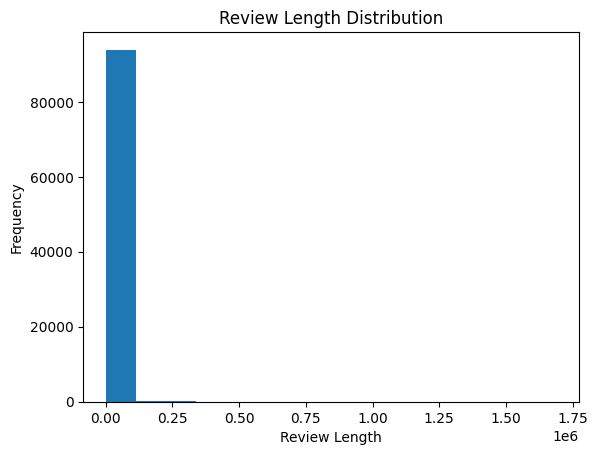

In [ ]:
plt.hist(item_reviews['text'].str.len(), bins=15)
plt.xlabel('Review Length')
plt.ylabel('Frequency')
plt.title('Review Length Distribution')
plt.show()

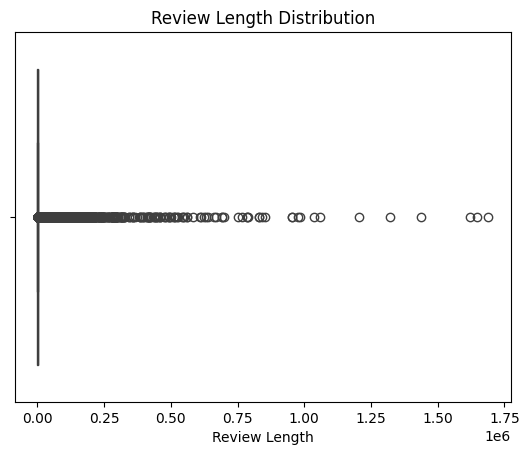

In [ ]:
review_lengths = item_reviews['text'].str.len()

sns.boxplot(x=review_lengths)
plt.xlabel('Review Length')
plt.title('Review Length Distribution')
plt.show()

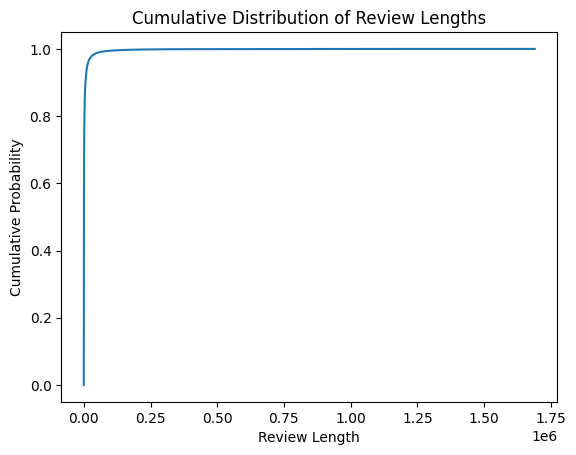

In [ ]:
import statsmodels.api as sm

ecdf = sm.distributions.ECDF(review_lengths)

plt.plot(ecdf.x, ecdf.y)
plt.xlabel('Review Length')
plt.ylabel('Cumulative Probability')
plt.title('Cumulative Distribution of Review Lengths')
plt.show()


In [ ]:
#review_lengths = item_reviews['text'].str.len() -- gives char length
review_lengths = item_reviews['text'].str.split().apply(len)

print("Min Review Length:", review_lengths.min())
print("Max Review Length:", review_lengths.max())
print("Mean Review Length:", review_lengths.mean())
print("Median Review Length:", review_lengths.median())
print("Standard Deviation:", review_lengths.std())

print("\n90th Percentile:", review_lengths.quantile(0.90))
print("95th Percentile:", review_lengths.quantile(0.95))
print("99th Percentile:", review_lengths.quantile(0.99))

Min Review Length: 0
Max Review Length: 317700
Mean Review Length: 710.7969974236368
Median Review Length: 73.0
Standard Deviation: 4624.68835129285

90th Percentile: 1114.0
95th Percentile: 2391.0
99th Percentile: 10564.379999999932


Median is 73%, so basically half of the reviews are upto 73 words. So this is a skewed distribution where some users are writing paragraphs.

In [ ]:
from scipy.stats import percentileofscore

specific_length = 250
percentile_rank = percentileofscore(review_lengths, specific_length)

print(f"Review length of {specific_length} words is at the {percentile_rank:.2f}th percentile.")

Review length of 250 words is at the 72.20th percentile.


0 length is of 0.02 percentile.

In [ ]:
user_reviews.head()

,user_id,text
0,AE22236AFRRSMQIKGG7TPTB75QEA,It turns water into ice. And it's a pretty bl...
1,AE2225K3KY4D3KKSN6I2AHBVR4QQ,My parents have an old Whirlpool washing machi...
2,AE222623DP4EJOFJCHTT4JBHHEKQ,The transaction was smooth. No issues at all. ...
3,AE222BXSMOAK65FICCF3SAG2FTIA,Fixed dryer. Better price than in a store
4,AE222D66NEFEM4KJMY663LKZPFTQ,every thing came in fine thanks


In [ ]:
#this cell is a joke. It took a whole 9 fucking minutes.

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

item_reviews['processed_review'] = item_reviews['text'].apply(preprocess_text)
user_reviews['processed_review'] = user_reviews['text'].apply(preprocess_text)

In [ ]:
MAX_WORDS = 10000
MAX_LEN = 250

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<UNK>")
tokenizer.fit_on_texts(item_reviews['processed_review'].tolist() + user_reviews['processed_review'].tolist())

item_reviews['seq'] = tokenizer.texts_to_sequences(item_reviews['processed_review'])
user_reviews['seq'] = tokenizer.texts_to_sequences(user_reviews['processed_review'])

item_reviews['padded_seq'] = pad_sequences(item_reviews['seq'], maxlen=MAX_LEN, padding='post').tolist()
user_reviews['padded_seq'] = pad_sequences(user_reviews['seq'], maxlen=MAX_LEN, padding='post').tolist()

In [ ]:
print(np.array(item_reviews['padded_seq']).shape)
print(np.array(user_reviews['padded_seq']).shape)

#for some reason, this gives a 1D instead of 2D, so do tolist()

(94319,)
(1755732,)


In [ ]:
item_reviews_padded = np.array(item_reviews['padded_seq'].tolist())
print(item_reviews_padded.shape)

user_reviews_padded = np.array(user_reviews['padded_seq'].tolist())
print(user_reviews_padded.shape)